# Trapezoidal Rule (Single & Composite)
The easiest way to find the area under a curve is to draw straight lines connecting points on the curve, which forms trapezoids. We just calculate the area of those trapezoids.

### The Math
For a single panel between $a$ and $b$, the area of the trapezoid is:
$$ \text{Area} = \frac{b - a}{2} (f(a) + f(b)) $$

If we chop the area into $m$ small trapezoids of width $h = \frac{b - a}{m}$, we sum them up to get the Composite Trapezoidal Rule:
$$ \int_a^b f(x) dx \approx \frac{h}{2} \left[ f(x_0) + 2 \sum_{i=1}^{m-1} f(x_i) + f(x_m) \right] $$

Notice that the points in the middle get multiplied by 2, because they form the boundary of *two* adjacent trapezoids, while the start and end points are only used once.

In [2]:
import numpy as np

def f(x):
    return x**2

def trapezoidal_single(f, a, b):
    h = b - a
    area = h * (f(a) + f(b)) / 2
    return area

def trapezoidal_composite(f, a, b, num_panels):
    h = (b - a) / num_panels
    x = np.linspace(a, b, num_panels + 1)
    
    # Area = h/2 * [f(x_first) + 2*f(x_middles) + f(x_last)]
    # The middle points get counted twice because they touch two trapezoids
    area = (h / 2) * (f(x[0]) + 2 * np.sum(f(x[1:-1])) + f(x[-1]))
    return area

# Example usage
print("Single Trapezoid Area:", trapezoidal_single(f, 0, 1))
print("Composite Trapezoid Area (100 panels):", trapezoidal_composite(f, 0, 1, 100))


Single Trapezoid Area: 0.5
Composite Trapezoid Area (100 panels): 0.33335000000000004


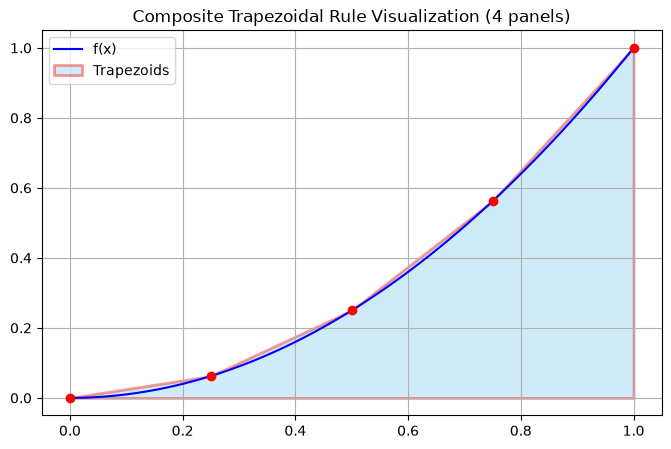

In [3]:
import matplotlib.pyplot as plt
import numpy as np
x_fine = np.linspace(0, 1, 100)
y_fine = f(x_fine)
x_trap = np.linspace(0, 1, 5)
y_trap = f(x_trap)
plt.figure(figsize=(8, 5))
plt.plot(x_fine, y_fine, 'b-', label='f(x)')
plt.fill_between(x_trap, 0, y_trap, color='skyblue', alpha=0.4, edgecolor='r', linewidth=2, label='Trapezoids')
plt.plot(x_trap, y_trap, 'ro')
plt.title('Composite Trapezoidal Rule Visualization (4 panels)')
plt.legend()
plt.grid(True)
plt.show()
